In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

customer_df = pd.read_csv("customer_features.csv")
orders_df = pd.read_csv("master_orders.csv")

In [2]:
#1. Overall Customer Satisfaction
#Average Review Score
print(f"Average Customer Review Score: {customer_df['average_review'].mean():.2f}")

Average Customer Review Score: 4.08


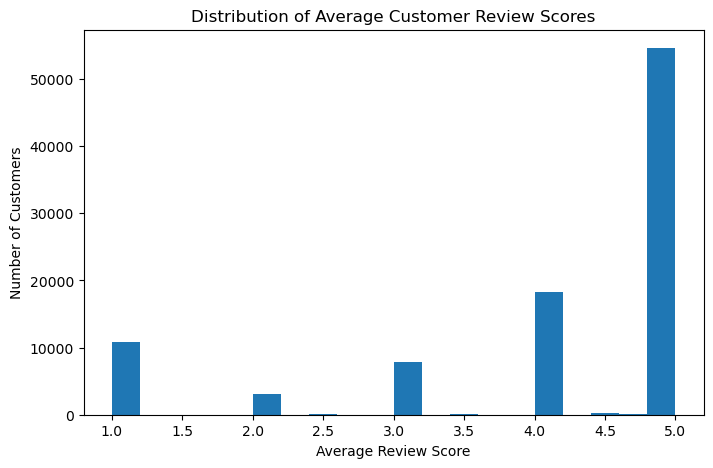

In [3]:
#Distribution of Customer Satisfaction
plt.figure(figsize=(8,5))
plt.hist(customer_df["average_review"], bins=20)
plt.title("Distribution of Average Customer Review Scores")
plt.xlabel("Average Review Score")
plt.ylabel("Number of Customers")
plt.show()

1) The majority of customers have an average review score above 4, indicating generally high customer satisfaction.

2) A relatively small proportion of customers report low average ratings, suggesting that negative experiences are limited.

3) The distribution indicates that the platform has maintained a positive overall shopping experience.

4) Monitoring customers with consistently low ratings can help identify recurring operational issues.

In [4]:
#2. Satisfaction Categories
customer_df["Satisfaction_Level"] = pd.cut(
    customer_df["average_review"],
    bins=[0,2,3.5,5],
    labels=["Low","Medium","High"],
    include_lowest=True
)

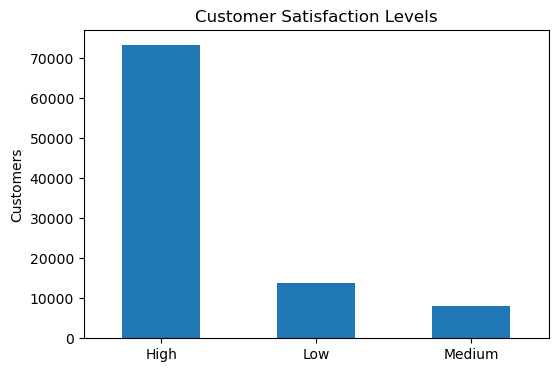

In [5]:
customer_df["Satisfaction_Level"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)
plt.title("Customer Satisfaction Levels")
plt.xlabel("")
plt.ylabel("Customers")
plt.xticks(rotation=0)
plt.show()

1) Most customers belong to the High Satisfaction category.

2) The Medium Satisfaction segment represents customers who could potentially become highly satisfied through service improvements.

3) The Low Satisfaction segment is relatively small but represents customers with a higher likelihood of churn.

4) Customer satisfaction segmentation helps prioritize retention strategies.

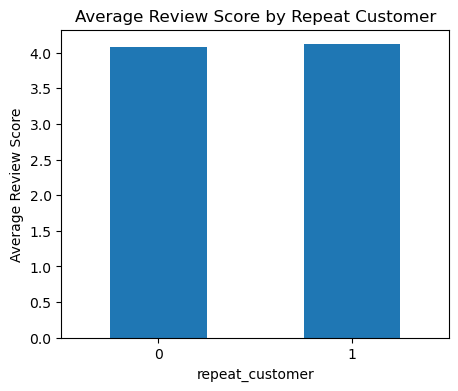

In [6]:
#3. Repeat Customers vs Satisfaction
repeat_review = (
    customer_df
    .groupby("repeat_customer")["average_review"]
    .mean()
)
plt.figure(figsize=(5,4))
repeat_review.plot(kind="bar")
plt.title("Average Review Score by Repeat Customer")
plt.ylabel("Average Review Score")
plt.xticks(rotation=0)
plt.show()

1) Comparing repeat and non-repeat customers helps assess the relationship between loyalty and satisfaction.

2) Higher ratings among repeat customers suggest that positive experiences encourage repeat purchases.

3) Lower ratings among repeat customers may indicate declining customer experience over time.

4) This analysis highlights the importance of maintaining consistent service quality.

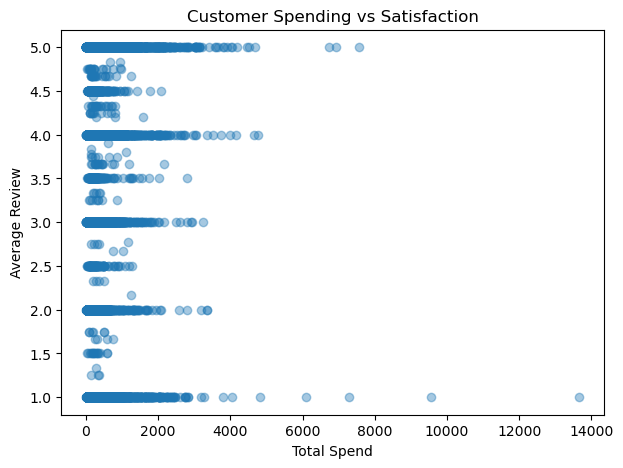

In [7]:
#6. Spending vs Satisfaction
plt.figure(figsize=(7,5))
plt.scatter(
    customer_df["total_spent"],
    customer_df["average_review"],
    alpha=0.4
)
plt.xlabel("Total Spend")
plt.ylabel("Average Review")
plt.title("Customer Spending vs Satisfaction")
plt.show()

1) Customer spending varies considerably across the platform, while satisfaction remains relatively consistent.

2) High-spending customers generally expect better service quality and shopping experiences.

3) Dissatisfied high-value customers should be identified and prioritized for retention initiatives.

4) Improving the experience of valuable customers can contribute significantly to long-term revenue growth.

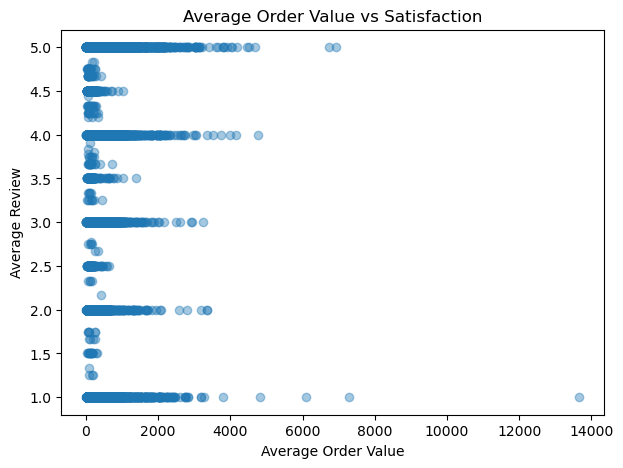

In [8]:
#7. Average Order Value vs Satisfaction
plt.figure(figsize=(7,5))
plt.scatter(
    customer_df["average_order_value"],
    customer_df["average_review"],
    alpha=0.4
)
plt.xlabel("Average Order Value")
plt.ylabel("Average Review")
plt.title("Average Order Value vs Satisfaction")
plt.show()

1) Customers placing higher-value orders generally expect better product quality and delivery performance.

2) A consistently high review score across different order values indicates reliable service quality.

3) Lower ratings for higher-value purchases may highlight opportunities to improve premium customer experiences.

4) Monitoring average order value alongside satisfaction supports customer relationship management.

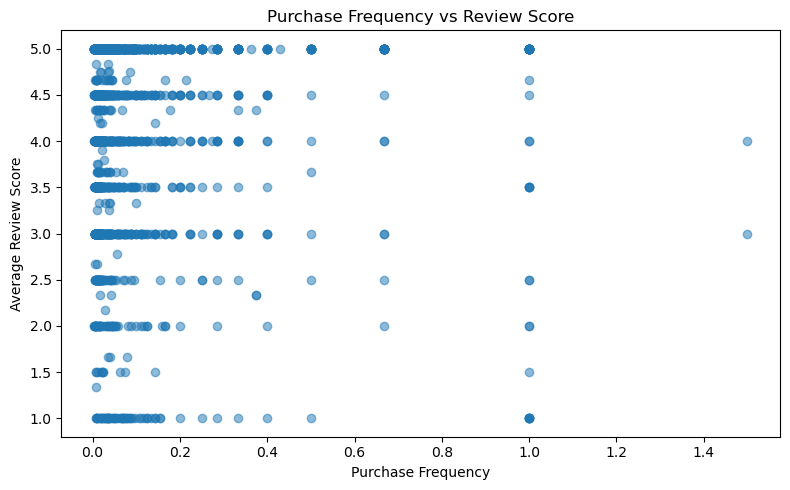

In [9]:
#5. Purchase Behaviour vs Satisfaction
plt.figure(figsize=(8,5))

plt.scatter(
    customer_df["purchase_frequency"],
    customer_df["average_review"],
    alpha=0.5
)
plt.title("Purchase Frequency vs Review Score")
plt.xlabel("Purchase Frequency")
plt.ylabel("Average Review Score")
plt.tight_layout()
plt.show()

1) Customers with higher purchase frequency generally demonstrate stronger engagement with the platform.

2) Frequent purchases combined with high ratings indicate customer loyalty and positive shopping experiences.

3) Customers with frequent purchases but lower satisfaction should be monitored to reduce future churn.

4) Purchase frequency provides useful insights into long-term customer behaviour.

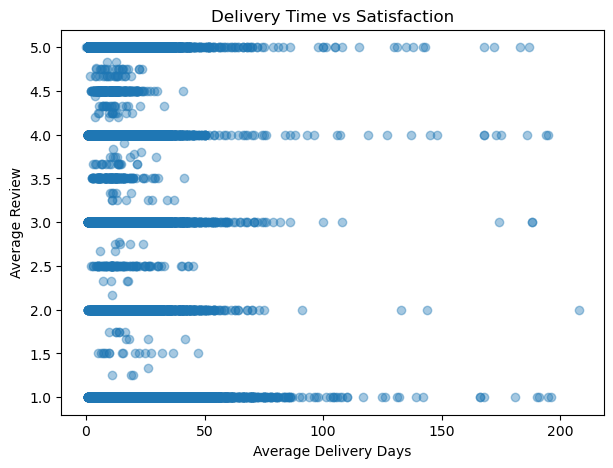

In [10]:
#8. Delivery Time vs Satisfaction
plt.figure(figsize=(7,5))
plt.scatter(
    customer_df["average_delivery_days"],
    customer_df["average_review"],
    alpha=0.4
)
plt.xlabel("Average Delivery Days")
plt.ylabel("Average Review")
plt.title("Delivery Time vs Satisfaction")
plt.show()

1) Delivery time has a noticeable influence on customer satisfaction.

2) Customers receiving orders within shorter delivery periods generally provide higher ratings.

3) Longer delivery durations may reduce customer satisfaction due to increased waiting times.

4) Improving delivery efficiency can positively influence overall customer experience.

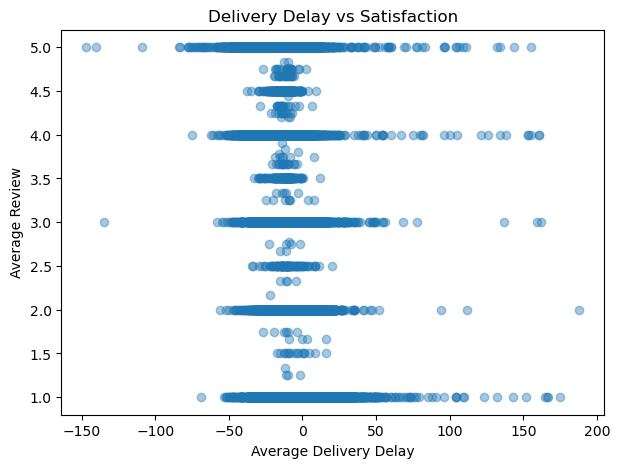

In [11]:
#9. Delivery Delay vs Satisfaction
plt.figure(figsize=(7,5))
plt.scatter(
    customer_df["average_delivery_delay"],
    customer_df["average_review"],
    alpha=0.4
)
plt.xlabel("Average Delivery Delay")
plt.ylabel("Average Review")
plt.title("Delivery Delay vs Satisfaction")
plt.show()

1) Delivery delays have a direct impact on customer satisfaction.

2) Customers experiencing delayed deliveries are generally more likely to provide lower review scores.

3) On-time deliveries contribute to stronger customer trust and positive shopping experiences.

4) Reducing delivery delays should remain a key operational priority.

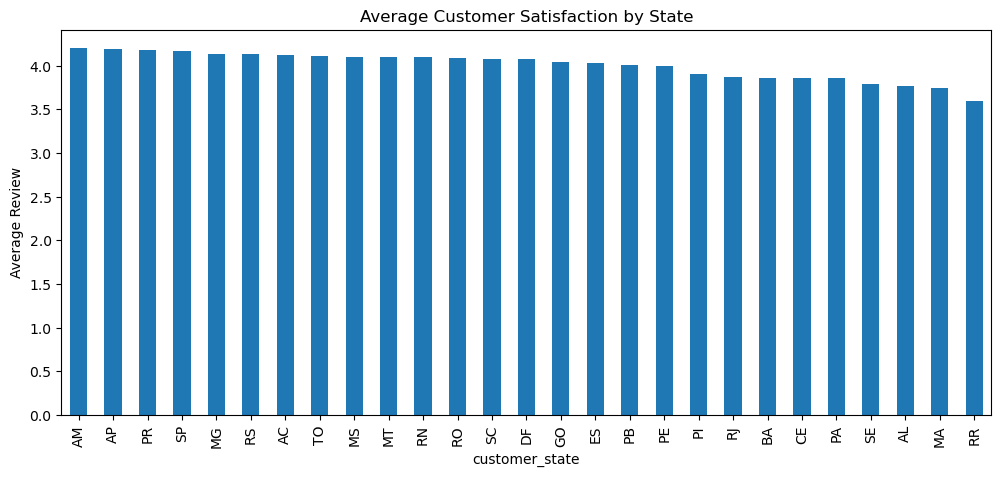

In [12]:
#10. Customer State Satisfaction
state_review = (
    customer_df
    .groupby("customer_state")["average_review"]
    .mean()
    .sort_values(ascending=False)
)
plt.figure(figsize=(12,5))
state_review.plot(kind="bar")
plt.title("Average Customer Satisfaction by State")
plt.ylabel("Average Review")
plt.xticks(rotation=90)
plt.show()

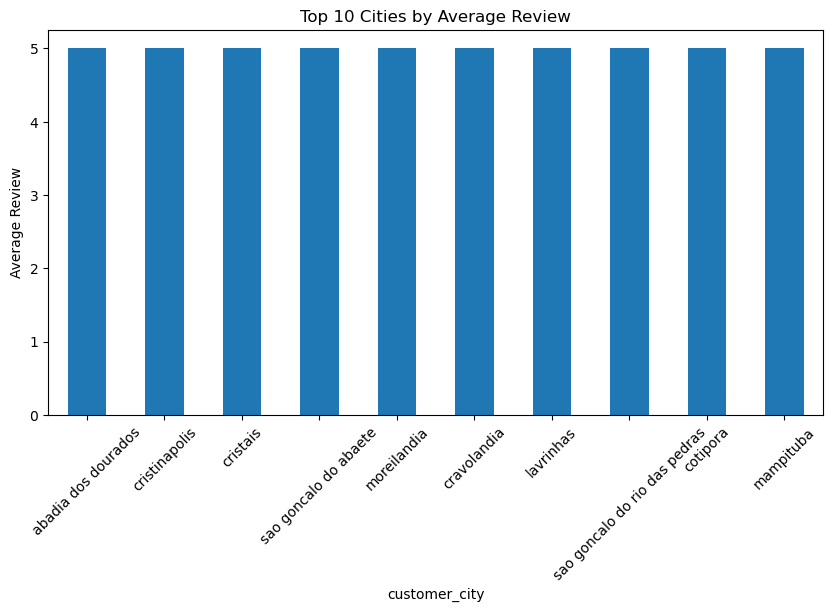

In [13]:
##12. Top 10 Cities by Satisfaction
city_review = (
    customer_df
    .groupby("customer_city")["average_review"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
plt.figure(figsize=(10,5))
city_review.plot(kind="bar")
plt.title("Top 10 Cities by Average Review")
plt.ylabel("Average Review")
plt.xticks(rotation=45)
plt.show()

1) Customer satisfaction varies across different states, indicating regional differences in customer experience.

2) States with higher average review scores demonstrate stronger operational and delivery performance.

3) Lower-rated states may require improvements in logistics, customer support, or product availability.

4) Regional satisfaction analysis helps identify areas requiring targeted operational improvements.

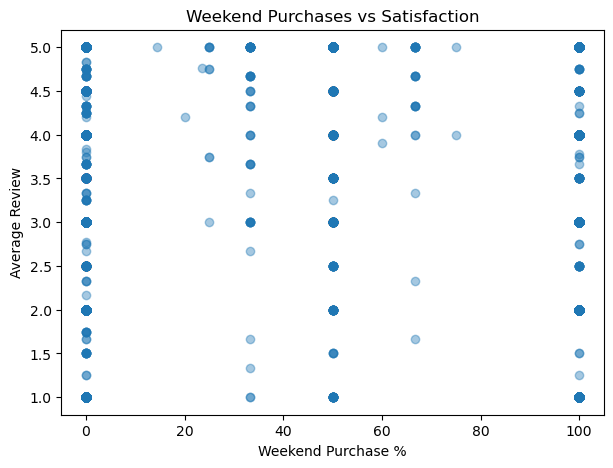

In [14]:
#13. Weekend Purchases vs Satisfaction
plt.figure(figsize=(7,5))
plt.scatter(
    customer_df["weekend_purchase_percentage"],
    customer_df["average_review"],
    alpha=0.4
)
plt.xlabel("Weekend Purchase %")
plt.ylabel("Average Review")
plt.title("Weekend Purchases vs Satisfaction")
plt.show()

1) Weekend purchasing behaviour provides insights into customer shopping preferences.

2) Similar review scores across different weekend purchase percentages indicate consistent service quality throughout the week.

3) Any noticeable decline in ratings among weekend shoppers may indicate higher operational pressure during peak demand.

4) Understanding weekend purchasing behaviour supports better workforce and inventory planning.

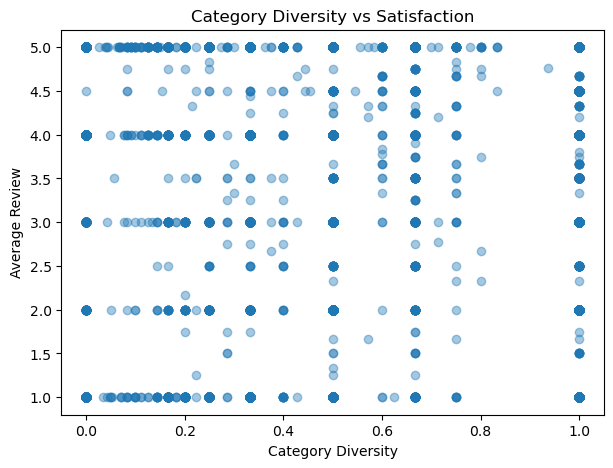

In [15]:
#14. Category Diversity vs Satisfaction
plt.figure(figsize=(7,5))
plt.scatter(
    customer_df["category_diversity_ratio"],
    customer_df["average_review"],
    alpha=0.4
)
plt.xlabel("Category Diversity")
plt.ylabel("Average Review")
plt.title("Category Diversity vs Satisfaction")
plt.show()

1) Customers purchasing products from multiple categories tend to exhibit greater engagement with the platform.

2) Higher category diversity may indicate stronger customer confidence in the available product range.

3) Consistently high satisfaction across diverse purchases reflects a reliable shopping experience.

4) Encouraging cross-category purchases may improve long-term customer retention.

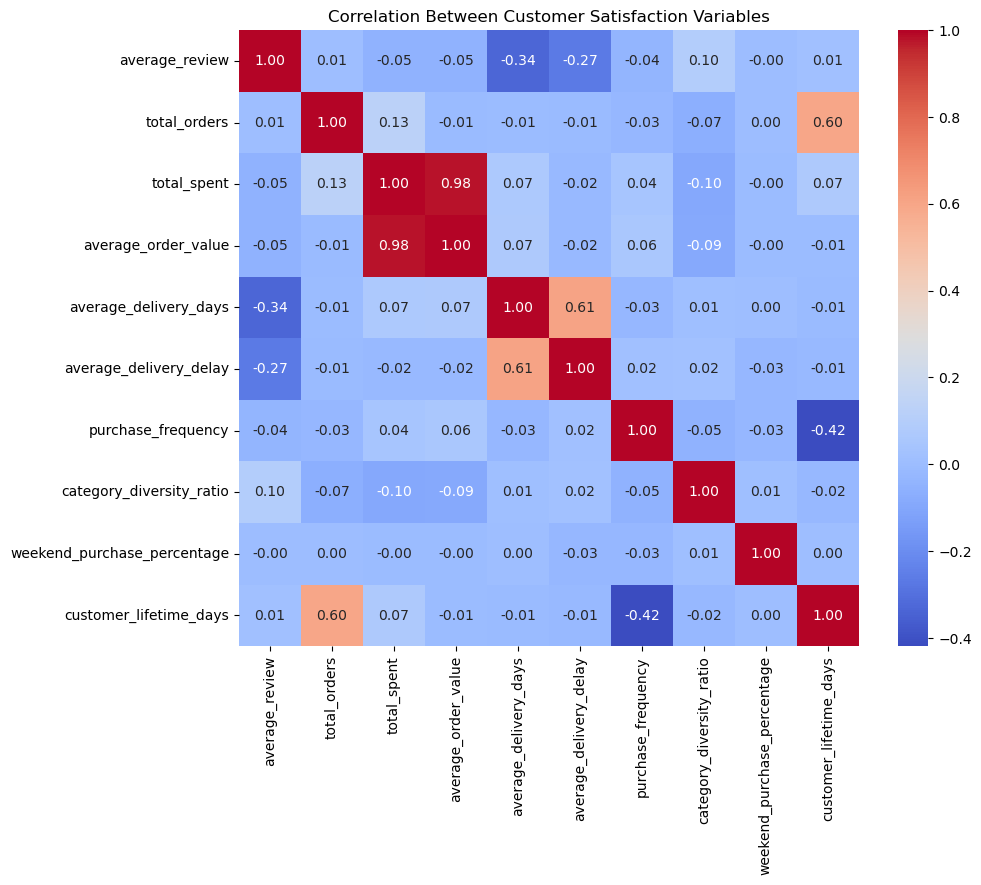

In [16]:
#15. Correlation Heatmap
corr_cols = [
    "average_review",
    "total_orders",
    "total_spent",
    "average_order_value",
    "average_delivery_days",
    "average_delivery_delay",
    "purchase_frequency",
    "category_diversity_ratio",
    "weekend_purchase_percentage",
    "customer_lifetime_days"
]
corr = customer_df[corr_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Between Customer Satisfaction Variables")
plt.show()

1) The heatmap summarizes the relationships between customer behaviour, spending patterns, delivery performance, and customer satisfaction.

2) Delivery-related variables generally exhibit stronger relationships with customer satisfaction than purchasing behaviour.

3) Weak correlations between certain variables indicate that customer satisfaction is influenced by multiple factors rather than a single metric.

4) Correlation analysis helps identify the most important variables affecting customer satisfaction and supports data-driven business decisions.

##### Supporting Analysis from master_orders

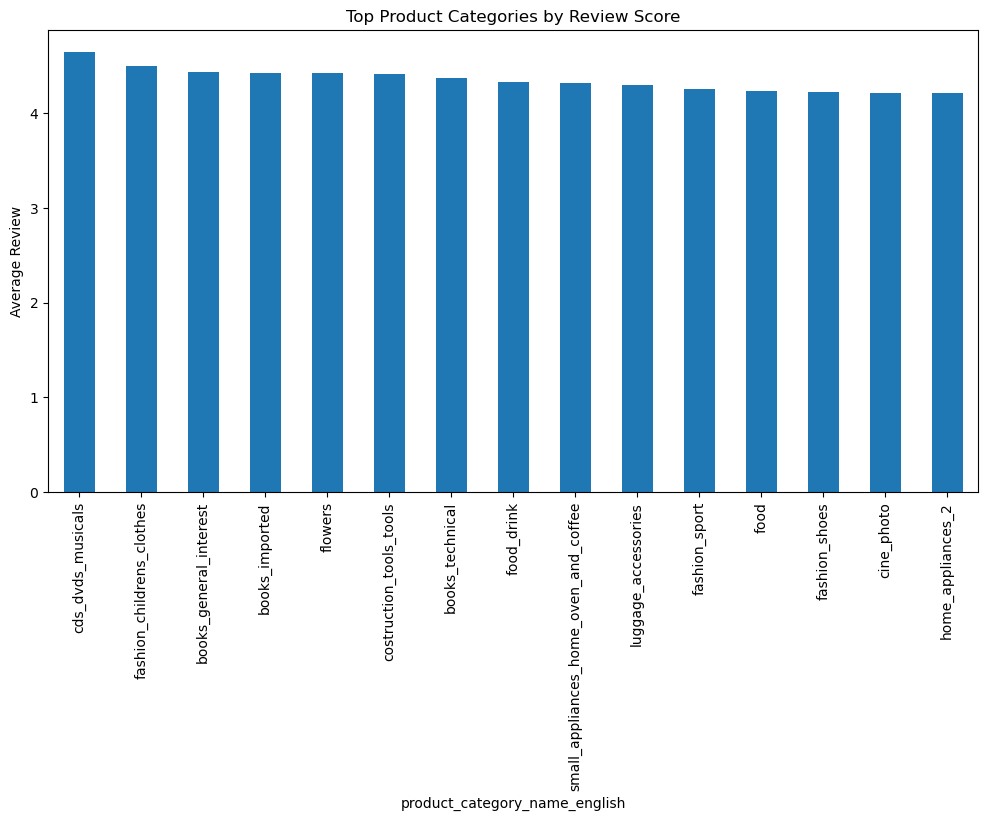

In [17]:
#16. Product Category Satisfaction
category_review = (
    orders_df
    .groupby("product_category_name_english")["review_score"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)
plt.figure(figsize=(12,6))
category_review.plot(kind="bar")
plt.title("Top Product Categories by Review Score")
plt.ylabel("Average Review")
plt.xticks(rotation=90)
plt.show()

1) Certain product categories consistently receive higher customer ratings than others.

2) High-performing categories indicate better product quality, customer expectations, and service performance.

3) These categories can serve as benchmarks for improving lower-performing product segments.

4) Promoting highly rated categories may contribute to increased customer confidence and sales.

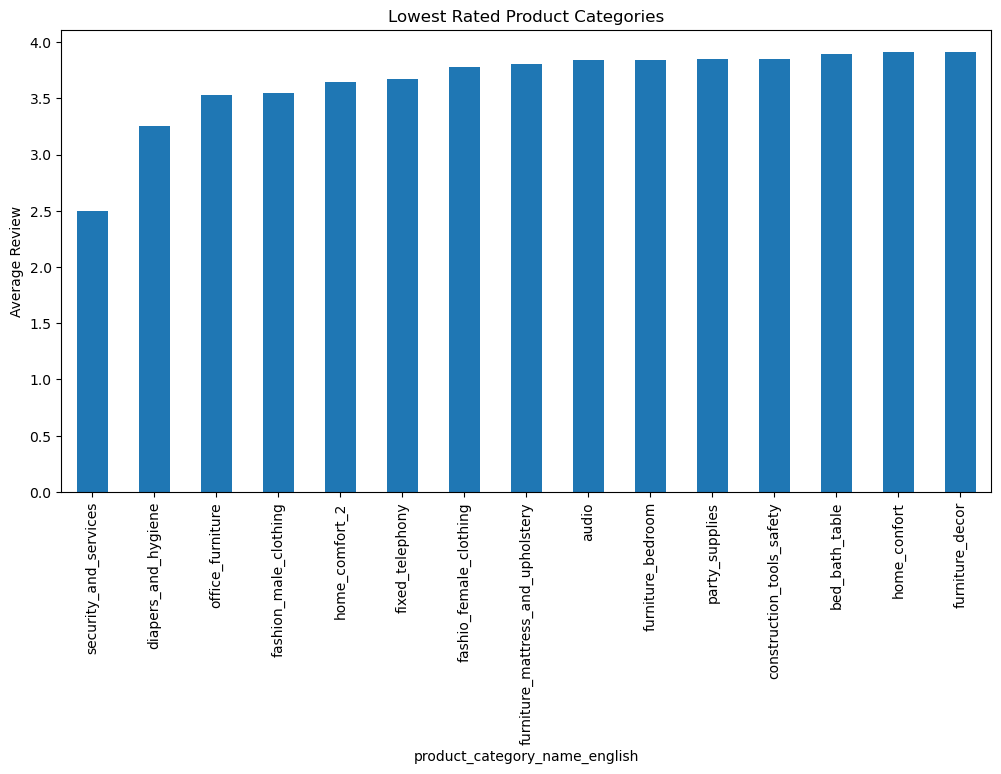

In [18]:
#17. Lowest Rated Categories
category_review = (
    orders_df
    .groupby("product_category_name_english")["review_score"]
    .mean()
    .sort_values()
    .head(15)
)
plt.figure(figsize=(12,6))
category_review.plot(kind="bar")
plt.title("Lowest Rated Product Categories")
plt.ylabel("Average Review")
plt.xticks(rotation=90)
plt.show()

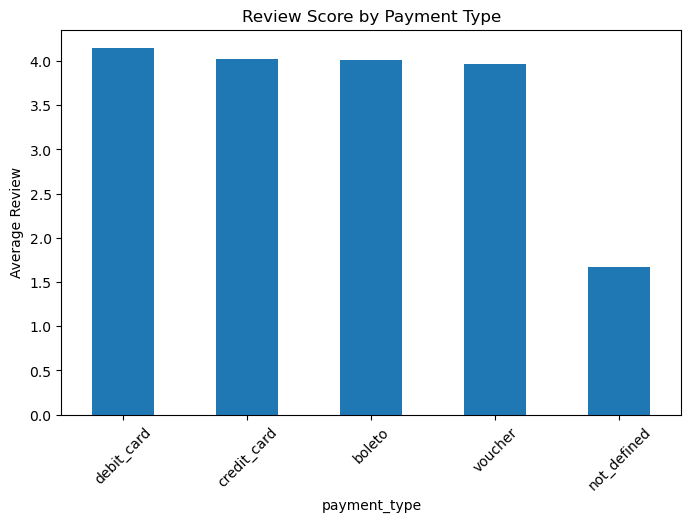

In [19]:
#18. Payment Type Satisfaction
payment_review = (
    orders_df
    .groupby("payment_type")["review_score"]
    .mean()
    .sort_values(ascending=False)
)
plt.figure(figsize=(8,5))
payment_review.plot(kind="bar")
plt.title("Review Score by Payment Type")
plt.ylabel("Average Review")
plt.xticks(rotation=45)
plt.show()

1) Customer satisfaction remains relatively consistent across different payment methods.

2) Minor differences in review scores may reflect variations in payment convenience or customer preferences.

3) A consistently positive experience across payment methods indicates reliable transaction processes.

4) Offering multiple secure payment options helps improve the overall customer experience.

In [20]:
#20. Customers Leaving Review Comments
comment_percentage = (
    orders_df["review_comment_message"]
    .notna()
    .mean()
)*100
print(f"Customers leaving written reviews: {comment_percentage:.2f}%")

Customers leaving written reviews: 42.17%
